In [1]:
import pandas as pd
import numpy as nd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Churn_Modelling-selected-columns.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3
3,4,15701354,Boni,699,France,Female,39,1,0.00,2
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1


In [8]:
print(len(df))
df.isnull().sum()
df.duplicated().sum()
df.describe()

10000


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000


In [10]:
# which country has the highest customer churn rate
df.head()
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

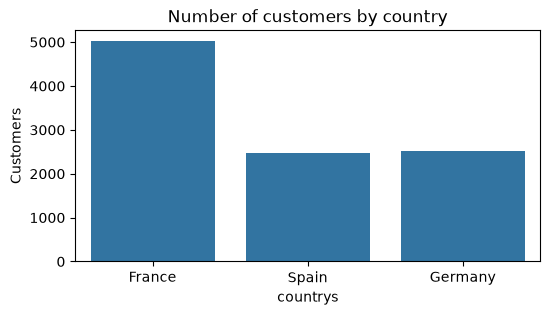

In [ ]:
# create countplot
plt.figure(figsize=(6,3))
sns.countplot(data=df, x='Geography')
plt.title('Number of customers by country')
plt.xlabel('countrys')
plt.ylabel('Customers')
plt.show()

In [18]:
# what is the age distribution of custumers
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

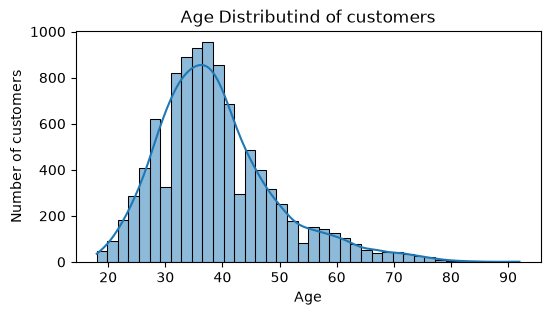

In [ ]:
# creates histplot
plt.figure(figsize=(6,3))
sns.histplot(data= df, x='Age', bins=40, kde=True)
plt.title('Age Distributind of customers')
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.show()


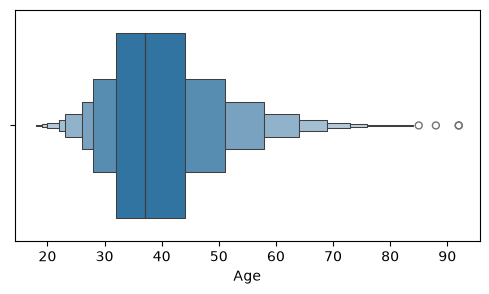

In [ ]:
plt.figure(figsize=(6,3))
sns.boxenplot(data= df, x= df['Age'])
plt.show()

In [32]:
# Does credit score vart across different countries
df.groupby('Geography')['CreditScore'].mean().round(2)


Geography
France     649.67
Germany    651.45
Spain      651.33
Name: CreditScore, dtype: float64

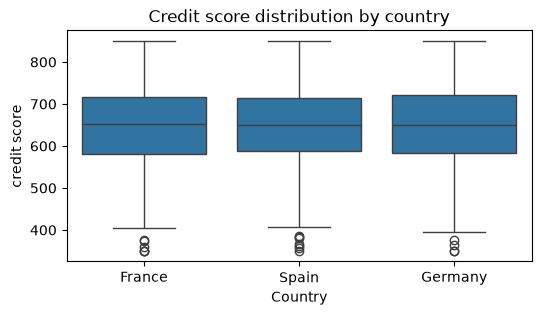

In [34]:
#create boxplot
plt.figure(figsize=(6,3))
sns.boxplot(data = df, x = 'Geography', y = 'CreditScore')
plt.title('Credit score distribution by country')
plt.xlabel('Country')
plt.ylabel('credit score')
plt.show()


In [37]:
# which country has the highest average account balance
avg_balance = df.groupby('Geography')['Balance'].mean().round(2).sort_values(ascending=False)
avg_balance

Geography
Germany    119730.12
France      62092.64
Spain       61818.15
Name: Balance, dtype: float64

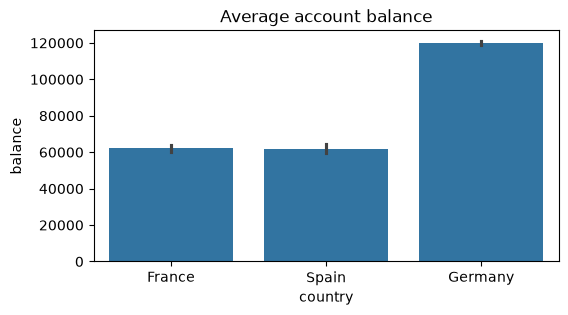

In [42]:
# create the barplot
plt.figure(figsize=(6,3))
sns.barplot(data=df, x= 'Geography', y='Balance',estimator='mean')
plt.title('Average account balance')
plt.xlabel('country')
plt.ylabel('balance')
plt.show()

In [ ]:
# which gender has the highest average account balance
df.groupby('Gender')['Balance'].mean().round(2).sort_values(ascending=False)

Gender
Male      77173.97
Female    75659.37
Name: Balance, dtype: float64

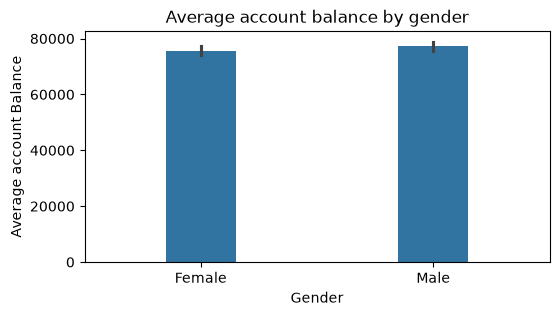

In [52]:
#create barplot
plt.figure(figsize=(6,3))
sns.barplot(data= df, x='Gender', y='Balance',width=0.3)
plt.title('Average account balance by gender')
plt.xlabel('Gender')
plt.ylabel('Average account Balance')
plt.show()

In [54]:
# does the number of bank products relate to account balance
df.groupby('NumOfProducts')['Balance'].mean().round(2)

NumOfProducts
1    98551.87
2    51879.15
3    75458.33
4    93733.14
Name: Balance, dtype: float64

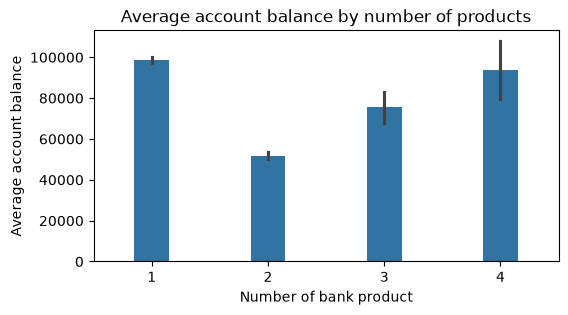

In [55]:
#create bar plot
plt.figure(figsize=(6,3))
sns.barplot(data= df, x= 'NumOfProducts', y='Balance', width=0.3)
plt.title('Average account balance by number of products')
plt.xlabel('Number of bank product')
plt.ylabel('Average account balance')
plt.show()